# <a href="https://thetahat.ru/courses/bm-hf-2026-spr">Математическая статистика (ФБМФ, ФМХФ)</a>
## Домашнее задание 1 &mdash; часть B

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить по ссылке "Сдача ДЗ" на странице курса. 
* Дедлайн см. на сайте и в боте. После дедлайна работы не принимаются **вообще никак**, кроме случаев наличия уважительной причины.
* До дедлайна можно поменять решение любое количество раз. 
* Любую уважительную причину нужно подтвердить документально, отправив скан или фото боту. При этом работу можно сдать позже на столько дней, на сколько время ее действия пересекается с временем выполнения задания.
* Прислать нужно **ноутбук в формате ipynb**. Другие форматы не принимаются.
* Выполнять задание необходимо **полностью самостоятельно**. При обнаружении списывания **все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Простой или основной уровень вы выбираете самостоятельно, выполняя или не выполняя задания типа B. При выборе **простого уровня** достаточно выполнить задания *типа A*. При выборе **основного уровня** нужно выполнять *как задания типа A, так и задания типа B*.
* Для выполнения задания используйте этот ноутбук в качествие основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами **удалять и изменять нельзя**, в противном случае соответствующее задание не будет оценено.
* Комментарии к решению пишите в markdown-ячейках.
* **Если код студента недописан и т.д., то он не оценивается.**
* Каждая задача стоит **5 баллов**.

_Замечание: перед выполнением задания можно ознакомиться с <a href="https://thetahat.ru/courses/bm-hf-2026-spr/stat/2/seminar2">ноутбуком с семинара</a>._

In [1]:
# Bot check

# HW_ID: st_1b
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [4]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from scipy.special import factorial, gammaln

### Задача 4

Оценку $\theta$ из задания 1.1 и оценку $a$ из задания 1.2 проверьте на несмещённость и состоятельность.

_Замечание: делайте необходимые пояснения по ходу доказательства._

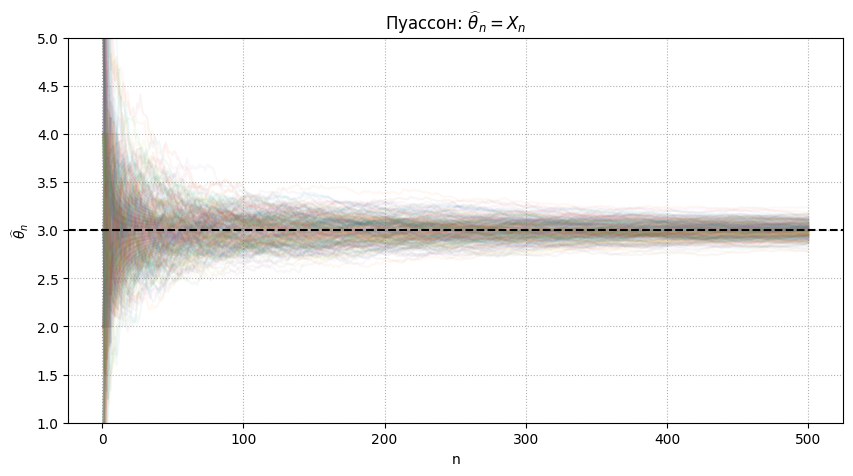

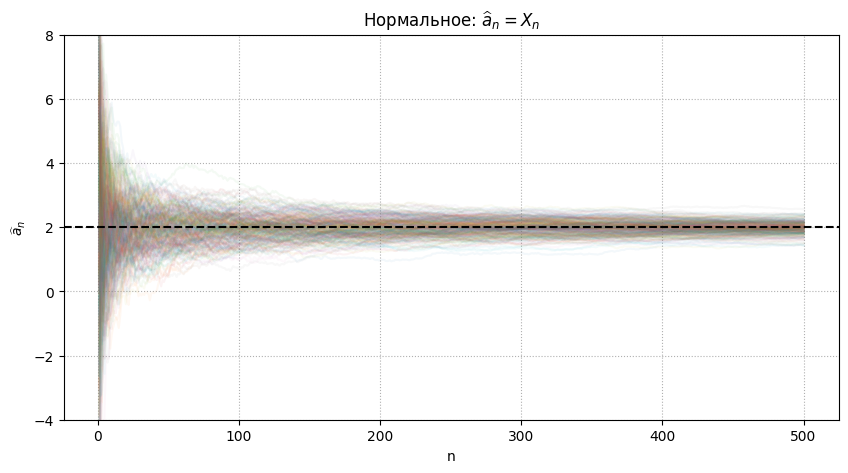

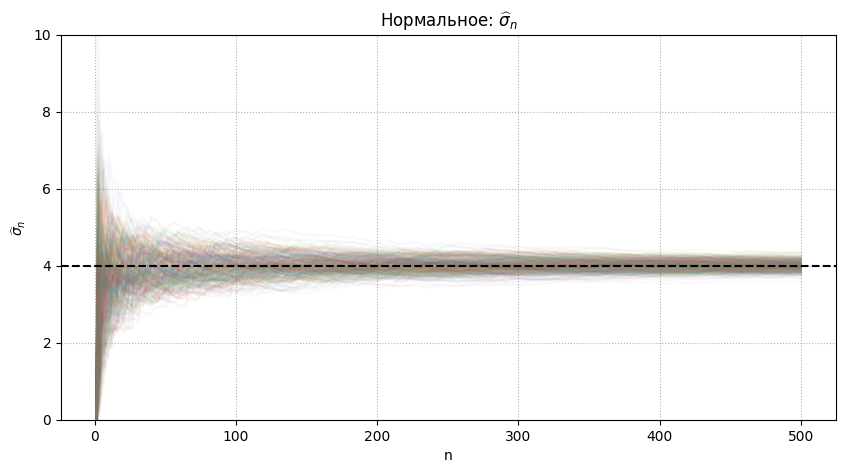

In [9]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from scipy.special import gammaln


# функции из задачи 1.1

def logfactorial(x):
    return gammaln(x + 1)


def poiss_loglikelihood(x, theta):
    return np.sum(x * np.log(theta) - theta - logfactorial(x))


def poiss_loglikelihood_grad(x, theta):
    return np.sum(x / theta - 1)


def poiss_maxlikelihood_estimator(x):
    return np.mean(x)


# функции из задачи 1.2

def norm_loglikelihood(x, a, sigma):
    return np.sum(
        -np.log(sigma)
        - 0.5 * np.log(2 * np.pi)
        - (x - a) ** 2 / (2 * sigma ** 2)
    )


def norm_loglikelihood_grad(x, a, sigma):
    n = len(x)

    grad_a = np.sum((x - a) / sigma ** 2)
    grad_sigma = -n / sigma + np.sum((x - a) ** 2 / sigma ** 3)

    return np.array([grad_a, grad_sigma])


def norm_maxlikelihood_estimator(x):
    a = np.mean(x)
    sigma = np.sqrt(np.mean((x - a) ** 2))

    return a, sigma


# параметры

np.random.seed(42)

sample_count = 300
sample_size = 500

n = np.arange(1, sample_size + 1)


# пуассон

theta_true = 3

x_poiss = sps.poisson(mu=theta_true).rvs((sample_count, sample_size))

# оценка theta по первым n элементам

poiss_estimations = np.cumsum(x_poiss, axis=1) / n

plt.figure(figsize=(10, 5))

for i in range(sample_count):
    plt.plot(n, poiss_estimations[i], alpha=0.05)

plt.axhline(theta_true, color="black", linestyle="--")
plt.xlabel("n")
plt.ylabel(r"$\widehat{\theta}_n$")
plt.title(r"Пуассон: $\widehat{\theta}_n =  X_n$")
plt.ylim(theta_true - 2, theta_true + 2)
plt.grid(ls=":")
plt.show()


# нормальное распределение

a_true = 2
sigma_true = 4

x_norm = sps.norm(loc=a_true, scale=sigma_true).rvs((sample_count, sample_size))


# оценка a по первым n элементам

a_estimations = np.cumsum(x_norm, axis=1) / n

plt.figure(figsize=(10, 5))

for i in range(sample_count):
    plt.plot(n, a_estimations[i], alpha=0.05)

plt.axhline(a_true, color="black", linestyle="--")
plt.xlabel("n")
plt.ylabel(r"$\widehat{a}_n$")
plt.title(r"Нормальное: $\widehat a_n =  X_n$")
plt.ylim(a_true - 6, a_true + 6)
plt.grid(ls=":")
plt.show()


# оценка sigma по первым n элементам

cumsum_x = np.cumsum(x_norm, axis=1)
cumsum_x2 = np.cumsum(x_norm ** 2, axis=1)

mean_x = cumsum_x / n
mean_x2 = cumsum_x2 / n

sigma_estimations = np.sqrt(mean_x2 - mean_x ** 2)

plt.figure(figsize=(10, 5))

for i in range(sample_count):
    plt.plot(n, sigma_estimations[i], alpha=0.05)

plt.axhline(sigma_true, color="black", linestyle="--")
plt.xlabel("n")
plt.ylabel(r"$\widehat{\sigma}_n$")
plt.title(r"Нормальное: $\widehat\sigma_n$")
plt.ylim(0, sigma_true + 6)
plt.grid(ls=":")
plt.show()

In [ ]:
# во всех случаях a_estimations стремится к teta_true, значит оценки верны и смещенности нет
# так то смещенность будет (может быть) для сигмы в последнем графике, так как точкой отсчета идет среднее выборки, а не заданное среднее, имхо это дает несущественное смещение 

__________________
### Задача 5

Загрузите данные об экспрессии гена FAM129A из файла `FAM129A.txt` с помощью функции `np.loadtxt`. Постройте гистограмму функцией `plt.hist`, указав в параметре `bins` оптимальное количество разбиений.

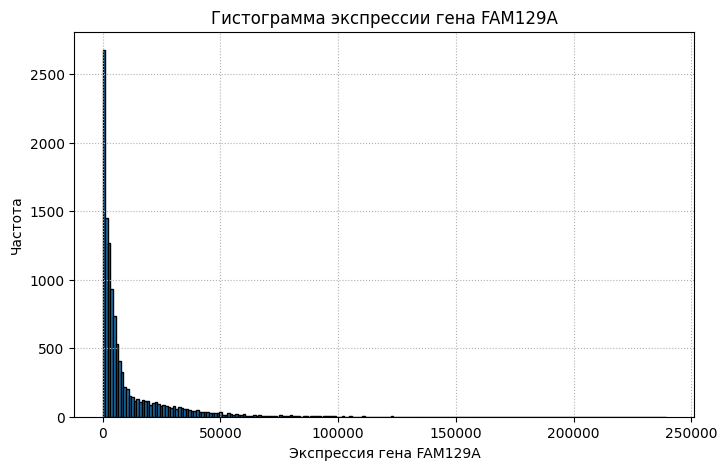

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# загружаем данные
x = np.loadtxt("FAM129A.txt")

# оптимальное число разбиений можно взять автоматически
plt.figure(figsize=(8, 5))
plt.hist(x, bins="auto", edgecolor="black")

plt.xlabel("Экспрессия гена FAM129A")
plt.ylabel("Частота")
plt.title("Гистограмма экспрессии гена FAM129A")
plt.grid(ls=":")
plt.show()

В предположении, что данные имеют пуассоновское распределение, найдите оценку максимального правдоподобия параметра распределения. Нарисуйте график дискретной плотности полученного распределения и сравните его с гистограммой. Хорошо ли оценка распределения приближает данные?

*Примечание:* для работы с распределениями случайных величин удобно пользоваться модулем <a href="https://thetahat.ru/courses/python/05">scipy.stats</a>.

theta_hat = 10034.47852498289


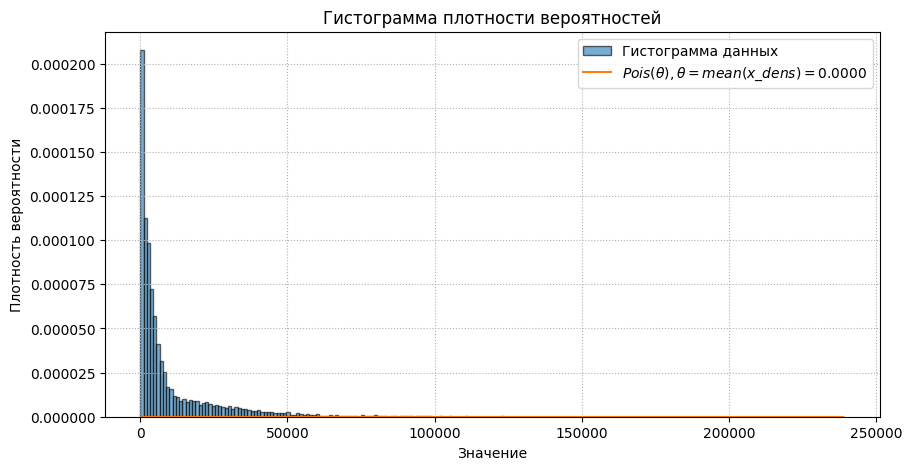

In [33]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

x = np.loadtxt("FAM129A.txt")

theta_hat = np.mean(x)

print("theta_hat =", theta_hat)

# бины ширины 1
bins = np.arange(np.min(x) - 0.5, np.max(x) + 1.5, 1)

plt.figure(figsize=(10, 5))

# гистограмма плотности вероятностей
x_dense, bins, _ = plt.hist(
    x,
    bins="auto", # не подощло
    density=True,
    edgecolor="black",
    alpha=0.6,
    label="Гистограмма данных"
)

theta_hat_true = np.mean(x_dense)
pmf_dens = sps.poisson(mu=theta_hat_true).pmf((bins[:-1] + bins[1:]) / 2)

plt.plot(
    (bins[:-1] + bins[1:]) / 2,
    pmf_dens,
    "-",
    label=rf"$Pois(\theta), \theta = mean(x\_dens) = {theta_hat_true:.4f}$"
)


plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.title("Гистограмма плотности вероятностей")
plt.grid(ls=":")
plt.legend()
plt.show()
# построилось что-то не то, попробуем по другому

theta_hat = 10034.47852498289


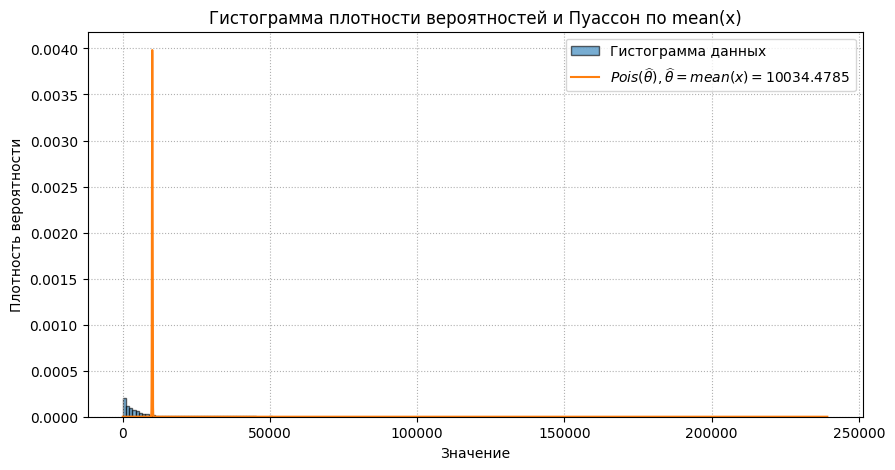

In [9]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

x = np.loadtxt("FAM129A.txt")

theta_hat = np.mean(x)
print("theta_hat =", theta_hat)

plt.figure(figsize=(10, 5))

x_dense, bins, _ = plt.hist(
    x,
    bins="auto",
    density=True,
    edgecolor="black",
    alpha=0.6,
    label="Гистограмма данных"
)

k = np.arange(int(np.min(x)), int(np.max(x)) + 1)

pmf = sps.poisson(mu=theta_hat).pmf(k)

plt.plot(
    k,
    pmf,
    "-",
    label=rf"$Pois(\widehat{{\theta}}), \widehat{{\theta}} = mean(x) = {theta_hat:.4f}$"
)

plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.title("Гистограмма плотности вероятностей и Пуассон по mean(x)")
plt.grid(ls=":")
plt.legend()
plt.show()
# а тут с дискретными, что дает не очень то хорошую оценку

theta_hat = 1003.447852498289


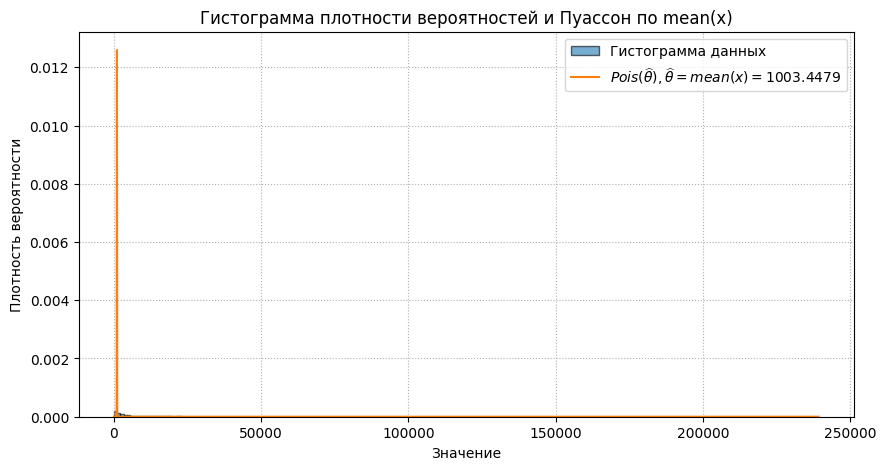

In [7]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

x = np.loadtxt("FAM129A.txt")

theta_hat = np.mean(x)
theta_hat = theta_hat / 10
print("theta_hat =", theta_hat)

plt.figure(figsize=(10, 5))

x_dense, bins, _ = plt.hist(
    x,
    bins="auto",
    density=True,
    edgecolor="black",
    alpha=0.6,
    label="Гистограмма данных"
)

k = np.arange(int(np.min(x)), int(np.max(x)) + 1)

pmf = sps.poisson(mu=theta_hat).pmf(k)

plt.plot(
    k,
    pmf,
    "-",
    label=rf"$Pois(\widehat{{\theta}}), \widehat{{\theta}} = mean(x) = {theta_hat:.4f}$"
)

plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.title("Гистограмма плотности вероятностей и Пуассон по mean(x)")
plt.grid(ls=":")
plt.legend()
plt.show()
# а тут с дискретными, что дает не очень то хорошую оценку

theta_hat = 100344.78524982888


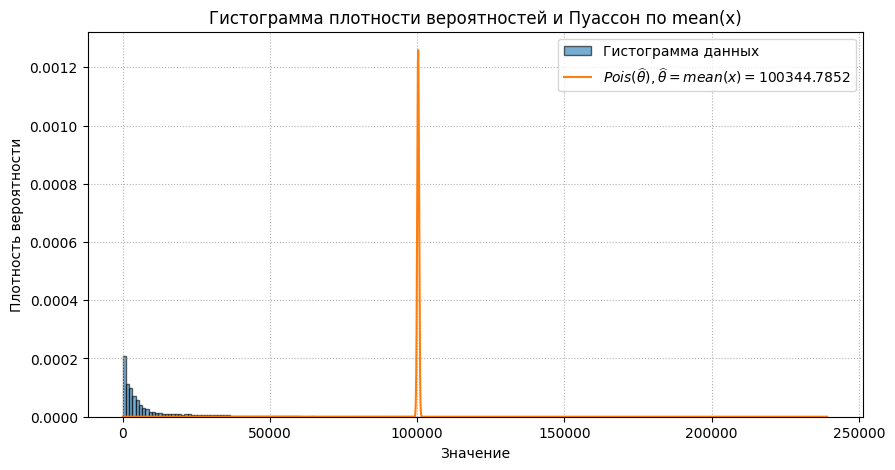

In [8]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

x = np.loadtxt("FAM129A.txt")

theta_hat = np.mean(x)
theta_hat = theta_hat * 10
print("theta_hat =", theta_hat)

plt.figure(figsize=(10, 5))

x_dense, bins, _ = plt.hist(
    x,
    bins="auto",
    density=True,
    edgecolor="black",
    alpha=0.6,
    label="Гистограмма данных"
)

k = np.arange(int(np.min(x)), int(np.max(x)) + 1)

pmf = sps.poisson(mu=theta_hat).pmf(k)

plt.plot(
    k,
    pmf,
    "-",
    label=rf"$Pois(\widehat{{\theta}}), \widehat{{\theta}} = mean(x) = {theta_hat:.4f}$"
)

plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.title("Гистограмма плотности вероятностей и Пуассон по mean(x)")
plt.grid(ls=":")
plt.legend()
plt.show()
# поигрался с тета, попытался подобрать иные значения, лучше всего всеткаи изначальное

In [ ]:
Итогом можно сказать, что не очень хорошая оценка, имеем пик, который слабо пересекается с изначальной гистограммой

__________________
### Задача 6
Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $U[0, \theta]$. Рассмотрим оценки 
* $2\overline{X}$, 
* $(n+1) \min_i X_i$,
* $\min_i X_i + \max_i X_i$,
* $\frac{n+1}{n} \max_i X_i$. 

Вам необходимо сравнить эти оценки в равномерном подходе с квадратичной и линейной функциями потерь, построив графики функций риска при помощи моделирования.

Для каждого $\theta \in (0, 2]$ с шагом $0.01$ сгенерируйте $5000$ независимых выборок $X^1=\left(X^1_1, \dots, X^1_{100} \right), \dots, X^{5000} = \left(X^{5000}_1, \dots, X^{5000}_{100} \right)$ из распределения $U[0, \theta]$.

(см. <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/seminar2.html#Задача-2.">пример с семинара</a>)

Рассмотрим одну из перечисленных выше оценок $\widehat{\theta}$. Посчитайте ее значение по каждой выборке. Тем самым, для данного $\theta$ получится $5000$ реализаций этой оценки $\widehat{\theta}_1, ..., \widehat{\theta}_{5000}$, где значение $\widehat{\theta}_j$ посчитано по реализации выборки $X^j$.

Теперь можно оценить функцию риска этой оценки с помощью усреднения
$$\widehat{R}_{\widehat{\theta}}(\theta) = \frac{1}{5000}\sum\limits_{j=1}^{5000} L\left(\widehat{\theta}_j, \theta\right),$$
где $L$ &mdash; одна из двух функций потерь: квадратичная $L(x, y)=(x-y)^2$ и линейная $L(x, y)=\left|x-y\right|$.

Для каждого из типов функций потерь постройте свой график. Нанесите на этот график для каждой из четырех оценок $\widehat{\theta}$ оценку функции потерь $\widehat{R}_{\widehat{\theta}}(\theta)$, пользуясь шаблоном ниже. Ограничение сверху по оси *y* ставьте таким, чтобы графики функции риска с малыми значениями четко различались.

*Совет*: при тестировании кода запускайте его с небольшими размерами данных. Например, используйте 100 реализаций выборок. Финальные результаты получите, поставив требуемые значения размеров данных.

В задаче допустимо использовать короткие циклы, то есть с малым количествои итераций.

In [ ]:
plt.plot(<сетка по параметру>, <функция риска>,
         label=<latex-метка>)  # для каждой оценки
plt.grid(ls=':')
plt.xlabel('$\\theta$', fontsize=16)
plt.ylabel('$\\widehat{R}_{\\widehat{\\theta}}(\\theta)$', fontsize=16)
plt.legend(fontsize=14)
plt.title(<тип функции потерь>, fontsize=16)
plt.ylim((0, <ограничение сверху>))

**Решение:**

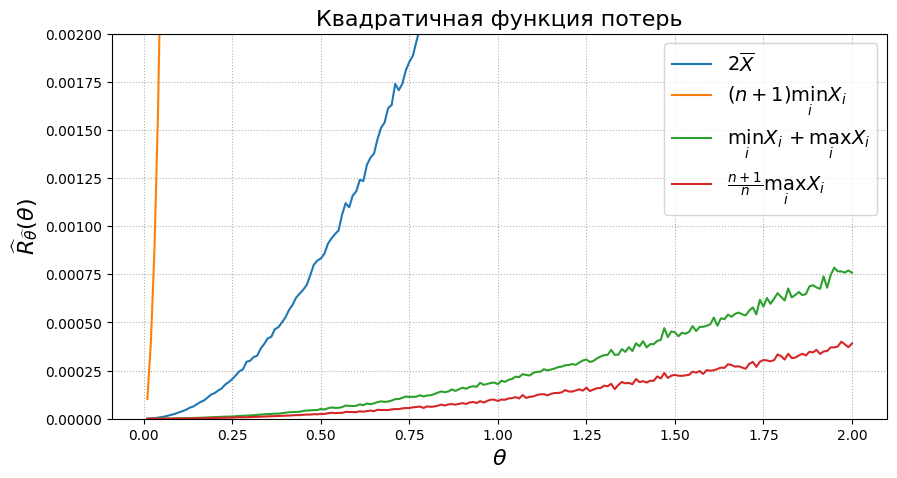

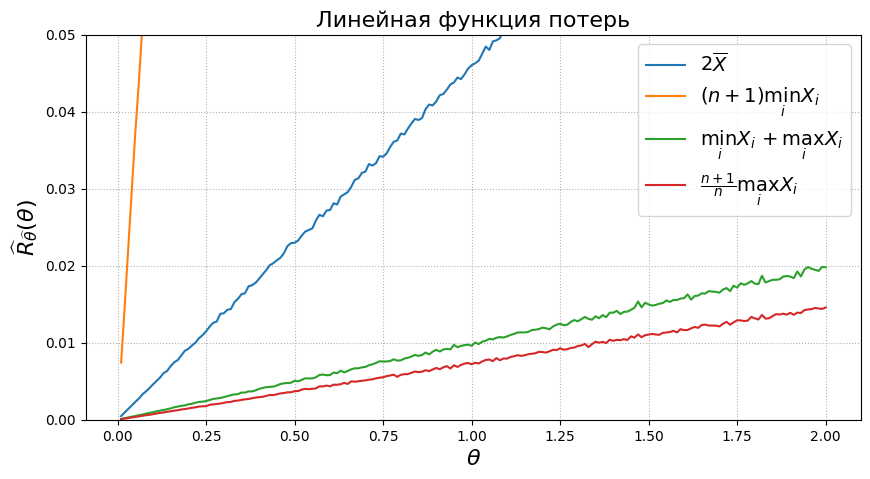

In [12]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100
sample_count = 5000

theta_grid = np.arange(0.01, 2.01, 0.01)

estimator_names = [
    r"$2\overline{X}$",
    r"$(n+1)\min_i X_i$",
    r"$\min_i X_i + \max_i X_i$",
    r"$\frac{n+1}{n}\max_i X_i$"
]

quadratic_risks = np.zeros((4, len(theta_grid)))
linear_risks = np.zeros((4, len(theta_grid)))

for idx, theta in enumerate(theta_grid):
    x = sps.uniform(loc=0, scale=theta).rvs((sample_count, n))

    x_mean = np.mean(x, axis=1)
    x_min = np.min(x, axis=1)
    x_max = np.max(x, axis=1)

    estimators = np.array([
        2 * x_mean,
        (n + 1) * x_min,
        x_min + x_max,
        (n + 1) / n * x_max
    ])

    quadratic_risks[:, idx] = np.mean((estimators - theta) ** 2, axis=1)
    linear_risks[:, idx] = np.mean(np.abs(estimators - theta), axis=1)


plt.figure(figsize=(10, 5))

for i in range(4):
    plt.plot(
        theta_grid,
        quadratic_risks[i],
        label=estimator_names[i]
    )

plt.grid(ls=':')
plt.xlabel('$\\theta$', fontsize=16)
plt.ylabel('$\\widehat{R}_{\\widehat{\\theta}}(\\theta)$', fontsize=16)
plt.legend(fontsize=14)
plt.title('Квадратичная функция потерь', fontsize=16)
plt.ylim((0, 0.002))
plt.show()


plt.figure(figsize=(10, 5))

for i in range(4):
    plt.plot(
        theta_grid,
        linear_risks[i],
        label=estimator_names[i]
    )

plt.grid(ls=':')
plt.xlabel('$\\theta$', fontsize=16)
plt.ylabel('$\\widehat{R}_{\\widehat{\\theta}}(\\theta)$', fontsize=16)
plt.legend(fontsize=14)
plt.title('Линейная функция потерь', fontsize=16)
plt.ylim((0, 0.05))
plt.show()

Сделайте вывод о том, какая оценка лучше и в каком подходе.

**Вывод:** 
Лучше функцией риска будет и при квадратичном и при линейном подходе (n+1)/n * max(x_i), очередность оценок пролучислась незавиясящая от линейности и квадратичности, в обоих случаях одинаковая, при больших тета врозможно и обратное, проверим
Хуже всего всегда была (n+1)minX_i, скорее всего из-за более быстрого убывания минимального значения, чем возрастания размера выборки (по карйне мере на практике), на втором с конца месте оценка через среднее, скорее всего это связано с отсчетом от среднего выборки и тем фактом что среднее выборки может плавать относителльно среднего распределения (попало несколько больших чисел -> среднее сместилось)

In [15]:
print("Лучшая оценка при квадратичной потере:")
print(estimator_names[np.argmin(np.max(quadratic_risks, axis=1))])

print("Лучшая оценка при линейной потере:")
print(estimator_names[np.argmin(np.max(linear_risks, axis=1))])

Лучшая оценка при квадратичной потере:
$\frac{n+1}{n}\max_i X_i$
Лучшая оценка при линейной потере:
$\frac{n+1}{n}\max_i X_i$


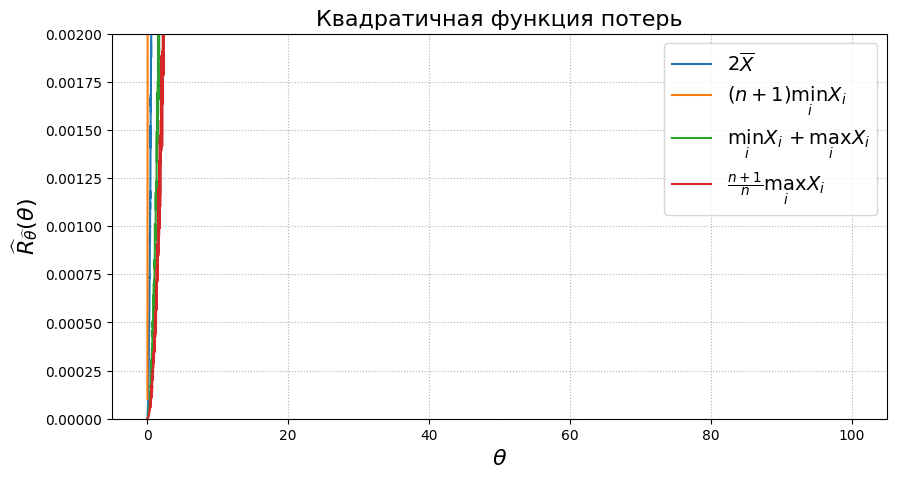

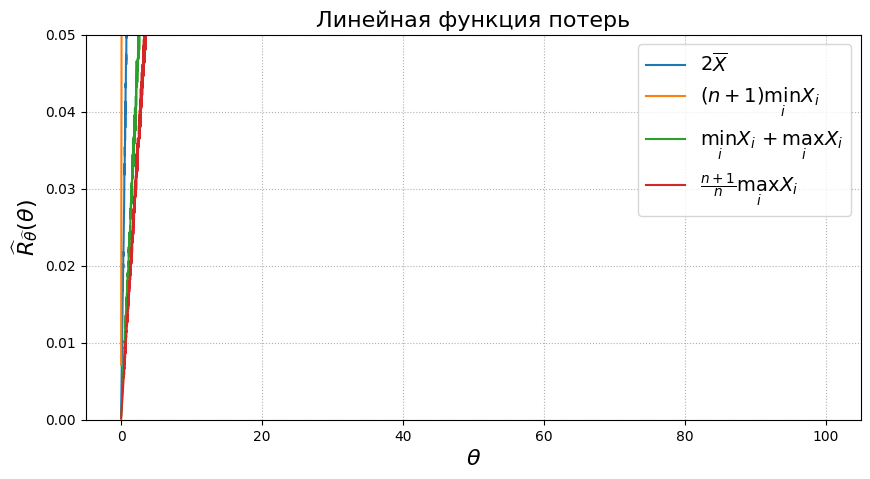

In [19]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

np.random.seed(42)

n = 50
sample_count = 1000

theta_grid = np.arange(0.01, 100.01, 0.01)

estimator_names = [
    r"$2\overline{X}$",
    r"$(n+1)\min_i X_i$",
    r"$\min_i X_i + \max_i X_i$",
    r"$\frac{n+1}{n}\max_i X_i$"
]

quadratic_risks = np.zeros((4, len(theta_grid)))
linear_risks = np.zeros((4, len(theta_grid)))

for idx, theta in enumerate(theta_grid):
    x = sps.uniform(loc=0, scale=theta).rvs((sample_count, n))

    x_mean = np.mean(x, axis=1)
    x_min = np.min(x, axis=1)
    x_max = np.max(x, axis=1)

    estimators = np.array([
        2 * x_mean,
        (n + 1) * x_min,
        x_min + x_max,
        (n + 1) / n * x_max
    ])

    quadratic_risks[:, idx] = np.mean((estimators - theta) ** 2, axis=1)
    linear_risks[:, idx] = np.mean(np.abs(estimators - theta), axis=1)


plt.figure(figsize=(10, 5))

for i in range(4):
    plt.plot(
        theta_grid,
        quadratic_risks[i],
        label=estimator_names[i]
    )

plt.grid(ls=':')
plt.xlabel('$\\theta$', fontsize=16)
plt.ylabel('$\\widehat{R}_{\\widehat{\\theta}}(\\theta)$', fontsize=16)
plt.legend(fontsize=14)
plt.title('Квадратичная функция потерь', fontsize=16)
plt.ylim((0, 0.002))
plt.show()


plt.figure(figsize=(10, 5))

for i in range(4):
    plt.plot(
        theta_grid,
        linear_risks[i],
        label=estimator_names[i]
    )

plt.grid(ls=':')
plt.xlabel('$\\theta$', fontsize=16)
plt.ylabel('$\\widehat{R}_{\\widehat{\\theta}}(\\theta)$', fontsize=16)
plt.legend(fontsize=14)
plt.title('Линейная функция потерь', fontsize=16)
plt.ylim((0, 0.05))
plt.show()

In [ ]:
# тут в общем то тоже все так, параболы похоже не пересекутся

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Статистики ФБМФ и ФЭФМ